<a href="https://colab.research.google.com/github/afthalla2929/MScBA-Files/blob/Project_and_Case_Studies/Copy_of_MBN603_Individual_Case_Study_OptionA_Online_Shoppers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Individual Case Study**
## Option A _ E-Commerce Purchase Intention Prediction  
**Ali Eissa - 20250007026**

**Course:** Programming for Data Analytics (MBN-603)

*The analysis is organised as a complete business analytics workflow: context, data preparation, modelling, evaluation, interpretation and actionable recommendations.*


## **1. Introduction**
An e-commerce firm wants to understand which behavioural characteristics of website visitors are associated with purchase completion. The target variable is **Revenue**, where `True` means the session ended with a transaction and `False` means it did not.

**Objective:** build a clean, reproducible classification pipeline using logistic regression to predict purchase intention and translate the model results into business recommendations.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

DATA_PATH = Path('online_shoppers_intention.csv')


## **2. Data Loading and First Inspection**


In [ ]:
df_raw = pd.read_csv(DATA_PATH)
print('Raw shape:', df_raw.shape)
df_raw.head()


Raw shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0000,0,0.0000,2,64.0000,0.0000,0.1000,0.0000,0.0000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0000,0,0.0000,2,2.6667,0.0500,0.1400,0.0000,0.0000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0000,0,0.0000,10,627.5000,0.0200,0.0500,0.0000,0.0000,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
audit_summary = pd.DataFrame({
    'metric': ['rows', 'columns', 'missing values', 'exact duplicates'],
    'value': [
        df_raw.shape[0],
        df_raw.shape[1],
        int(df_raw.isnull().sum().sum()),
        int(df_raw.duplicated().sum())
    ]
})
audit_summary


,metric,value
0,rows,12330
1,columns,18
2,missing values,0
3,exact duplicates,125


In [ ]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

### Variable classification
Although several fields are stored as integers, some of them represent coded categories rather than continuous numeric values. For modeling, the predictors are separated as follows:

- **Numeric:** Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues, SpecialDay
- **Categorical:** Month, OperatingSystems, Browser, Region, TrafficType, VisitorType, Weekend
- **Target:** Revenue


In [ ]:
categorical_cols = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
numeric_cols = [c for c in df_raw.columns if c not in categorical_cols + ['Revenue']]

pd.DataFrame({
    'numeric_variables': pd.Series(numeric_cols),
    'categorical_variables': pd.Series(categorical_cols)
})


,numeric_variables,categorical_variables
0,Administrative,Month
1,Administrative_Duration,OperatingSystems
2,Informational,Browser
3,Informational_Duration,Region
4,ProductRelated,TrafficType
5,ProductRelated_Duration,VisitorType
6,BounceRates,Weekend
7,ExitRates,NaN
8,PageValues,NaN
9,SpecialDay,NaN


## **3. Data Understanding and Preparation**


In [ ]:
# Remove exact duplicates to avoid repeated sessions influencing the model
df = df_raw.drop_duplicates().copy()
print('Rows after removing duplicates:', df.shape[0])
print('Duplicates removed:', df_raw.shape[0] - df.shape[0])


Rows after removing duplicates: 12205
Duplicates removed: 125


In [ ]:
# Cast categorical columns to string so the encoder treats them as categories, not numeric scales.
for col in categorical_cols:
    df[col] = df[col].astype(str)

class_distribution = (
    df['Revenue'].value_counts(normalize=True)
      .rename(index={False: 'No Purchase', True: 'Purchase'})
      .mul(100)
      .round(2)
)
class_distribution


,proportion
Revenue,
No Purchase,84.3700
Purchase,15.6300


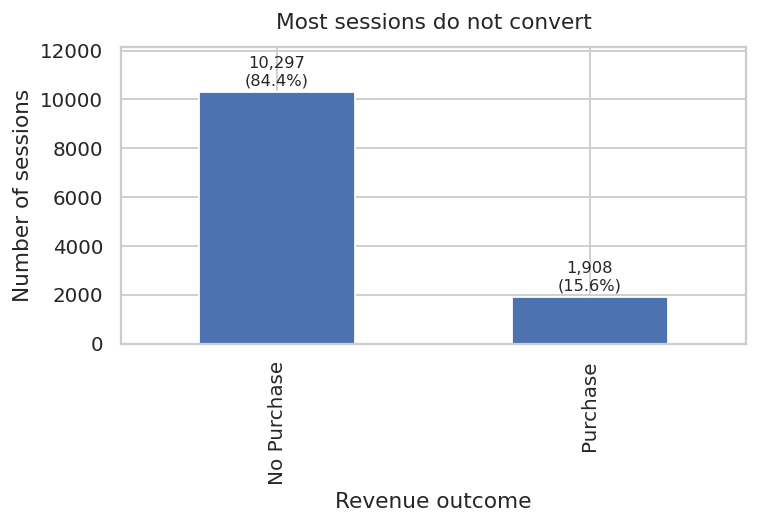

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.2))
counts = df['Revenue'].value_counts().rename(index={False: 'No Purchase', True: 'Purchase'})
counts.plot(kind='bar', ax=ax)
max_count = counts.max()
ax.set_ylim(0, max_count * 1.18)
ax.set_title('Most sessions do not convert', pad=10)
ax.set_ylabel('Number of sessions')
ax.set_xlabel('Revenue outcome')
for i, (label, value) in enumerate(counts.items()):
    pct = class_distribution[label]
    ax.text(i, value + max_count * 0.015, f'{value:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
# Exploratory summary by outcome
selected_numeric = ['Administrative', 'Administrative_Duration', 'ProductRelated',
                    'ProductRelated_Duration', 'ExitRates', 'PageValues']
summary_by_outcome = df.groupby('Revenue')[selected_numeric].mean().T
summary_by_outcome.columns = ['NoPurchase', 'Purchase']
summary_by_outcome['Difference'] = summary_by_outcome['Purchase'] - summary_by_outcome['NoPurchase']
summary_by_outcome.round(3)


,NoPurchase,Purchase,Difference
Administrative,2.1430,3.3940,1.2500
Administrative_Duration,74.6350,119.4830,44.8480
ProductRelated,29.0500,48.2100,19.1600
ProductRelated_Duration,"1,082.9770","1,876.2100",793.2330
ExitRates,0.0460,0.0200,-0.0260
PageValues,2.0000,27.2650,25.2650


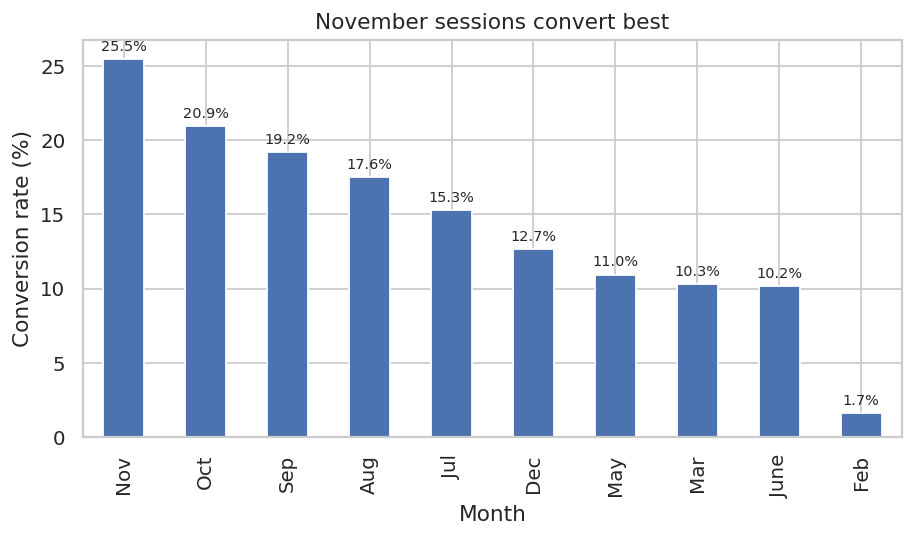

,Revenue
Month,
Nov,25.4900
Oct,20.9500
Sep,19.2000
Aug,17.5500
Jul,15.2800
Dec,12.6600
May,10.9600
Mar,10.3200
June,10.1800


In [ ]:
month_conversion = (
    df.groupby('Month')['Revenue']
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(7.2, 4.3))
month_conversion.plot(kind='bar', ax=ax)
ax.set_title('November sessions convert best')
ax.set_ylabel('Conversion rate (%)')
ax.set_xlabel('Month')
for i, value in enumerate(month_conversion.values):
    ax.text(i, value + 0.35, f'{value:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

month_conversion


### Preparation decisions
1. **Missing values:** none were found, so no imputation was needed.  
2. **Duplicates:** 125 exact duplicates were removed.  
3. **Categorical encoding:** one-hot encoding is used for non-numeric categories.  
4. **Feature engineering:** no synthetic interaction terms were added because the baseline model must remain interpretable. Feature engineering is therefore limited to correct typing, encoding, and scaling.  
5. **Scaling:** numeric variables are standardized so the logistic regression coefficients are more stable and comparable.


## **4. Modeling Methodology**


In [ ]:
y = df['Revenue'].astype(int)
X = df.drop(columns=['Revenue'])

# Fix category levels so the train/test pipeline remains stable.
category_levels = [sorted(X[col].unique().tolist()) for col in categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', categories=category_levels), categorical_cols)
    ]
)

log_reg_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=2000, solver='liblinear', random_state=42))
])

log_reg_model.fit(X_train, y_train)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)


Train size: (9764, 17)
Test size : (2441, 17)


**Why logistic regression?**
- It is an appropriate transparent baseline for a binary classification problem.
- It is appropriate for a binary target.
- It is easier to explain in a short presentation because coefficients show the direction of influence on purchase likelihood.


## **5. Results and Model Evaluation**


In [ ]:
y_pred = log_reg_model.predict(X_test)
y_prob = log_reg_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
naive_accuracy = (y_test == 0).mean()
cm = confusion_matrix(y_test, y_pred)

metrics_df = pd.DataFrame({
    'metric': ['Accuracy', 'Naive baseline accuracy', 'Precision', 'Recall', 'F1 score', 'ROC AUC'],
    'value': [accuracy, naive_accuracy, precision, recall, f1, roc_auc]
})
metrics_df['value'] = metrics_df['value'].round(4)
metrics_df


,metric,value
0,Accuracy,0.8882
1,Naive baseline accuracy,0.8435
2,Precision,0.7583
3,Recall,0.4188
4,F1 score,0.5396
5,ROC AUC,0.9000


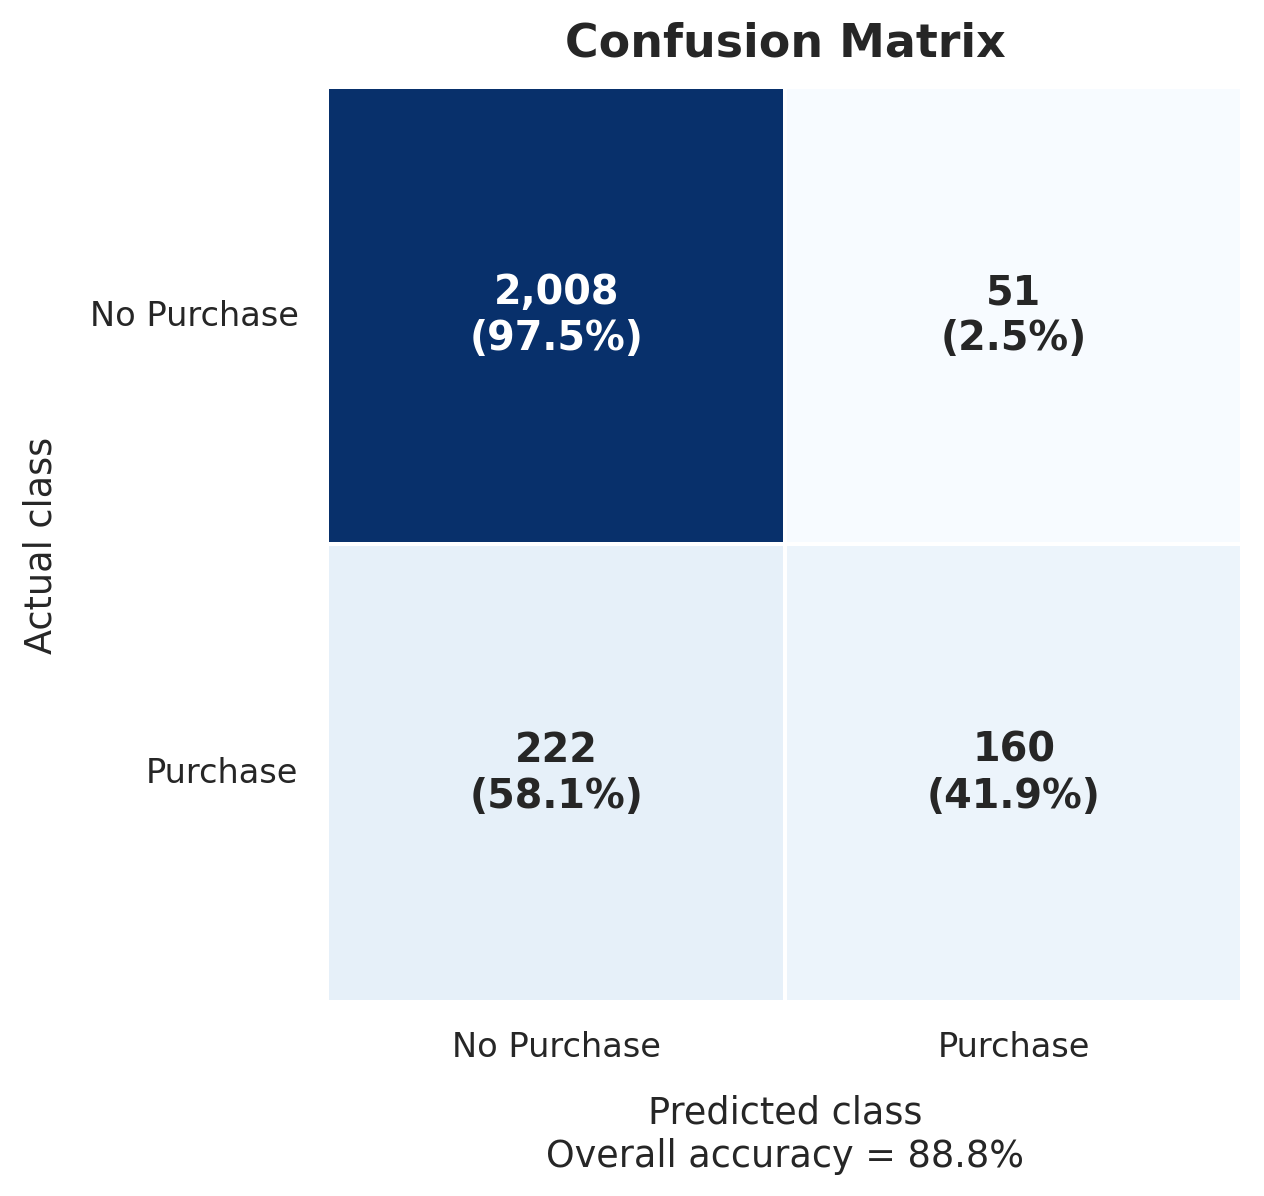

In [ ]:
fig, ax = plt.subplots(figsize=(6.6, 5.6), dpi=220)
cm_percent = cm / cm.sum(axis=1, keepdims=True)
cm_labels = np.array([
    [f"{cm[i, j]:,}\n({cm_percent[i, j]*100:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

sns.heatmap(
    cm,
    annot=cm_labels,
    fmt='',
    cbar=False,
    cmap='Blues',
    linewidths=1.2,
    linecolor='white',
    square=True,
    annot_kws={'fontsize': 13, 'fontweight': 'bold'},
    ax=ax
)

ax.set_title('Confusion Matrix', fontsize=15, fontweight='bold', pad=10)
ax.set_xlabel(f'Predicted class\nOverall accuracy = {accuracy*100:.1f}%', fontsize=12, labelpad=10)
ax.set_ylabel('Actual class', fontsize=12, labelpad=10)
ax.set_xticklabels(['No Purchase', 'Purchase'], fontsize=11)
ax.set_yticklabels(['No Purchase', 'Purchase'], fontsize=11, rotation=0)

plt.tight_layout()
plt.show()


### Interpretation of model performance
The model achieves **88.8% accuracy**, which is higher than the **84.4% naive baseline** that would predict every session as non-purchase. This shows the model adds value. However, the confusion matrix also shows that the model is much stronger at identifying non-buyers than buyers: it correctly classifies 2,008 non-purchase sessions but only 160 purchase sessions, while 222 buyers are missed. In business terms, the model is reliable for filtering low-intent traffic, but it should be used carefully if the goal is to capture every potential buyer.


## **6. Influential Variables**


In [ ]:
feature_names = log_reg_model.named_steps['preprocess'].get_feature_names_out()
coefficients = pd.Series(log_reg_model.named_steps['clf'].coef_[0], index=feature_names)

selected_features = [
    'num__PageValues',
    'num__ExitRates',
    'num__ProductRelated_Duration',
    'num__Administrative',
    'cat__Month_Nov',
    'cat__Month_Dec',
    'cat__VisitorType_Returning_Visitor',
    'cat__Weekend_True',
]

selected_coef_df = pd.DataFrame({
    'feature_code': selected_features,
    'label': ['PageValues', 'ExitRates', 'ProductRelated_Duration', 'Administrative',
              'Month = Nov', 'Month = Dec', 'Returning Visitor', 'Weekend = True'],
    'coefficient': [coefficients[f] for f in selected_features],
    'odds_ratio': [np.exp(coefficients[f]) for f in selected_features]
}).sort_values('coefficient', ascending=False)

selected_coef_df[['label', 'coefficient', 'odds_ratio']].round(4)


,label,coefficient,odds_ratio
0,PageValues,1.5232,4.5870
4,Month = Nov,0.4832,1.6212
2,ProductRelated_Duration,0.1356,1.1452
7,Weekend = True,0.1125,1.1191
3,Administrative,0.0507,1.0520
6,Returning Visitor,-0.1198,0.8871
5,Month = Dec,-0.6970,0.4981
1,ExitRates,-0.7806,0.4581


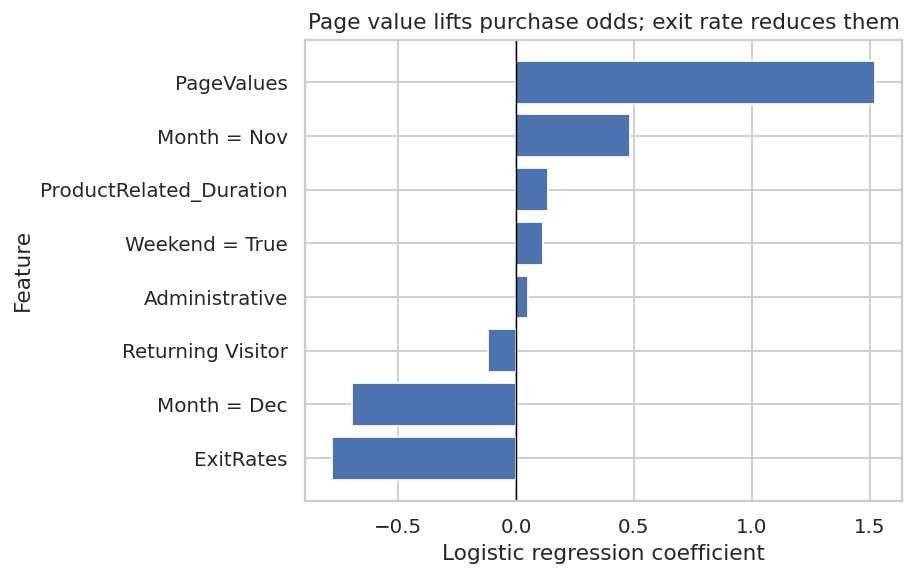

In [ ]:
plot_df = selected_coef_df.sort_values('coefficient')
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.barh(plot_df['label'], plot_df['coefficient'])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Page value lifts purchase odds; exit rate reduces them')
ax.set_xlabel('Logistic regression coefficient')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


### Main findings
- **PageValues** is the strongest positive predictor. Higher page value is associated with much higher purchase odds.
- **ExitRates** is the strongest negative business-relevant predictor. Sessions with high exit rates are less likely to convert.
- **ProductRelated_Duration** has a positive effect, suggesting deeper product browsing is linked to buying intent.
- **Month = Nov** is positive, matching the higher conversion rate seen in EDA.
- **Weekend = True** is slightly positive.
- **Returning Visitor** is slightly negative relative to the reference category, which suggests new visitors in this dataset sometimes arrive with stronger immediate purchase intent.


## **7. Business Implications and Recommendations**


### Recommendation 1 - Reduce exit points on high-intent pages
Since exit rate has a strong negative relationship with purchase completion, the business should audit the pages where users leave most often - especially product, cart, and checkout pages. Practical actions include simplifying checkout steps, improving page speed, clarifying delivery information, and testing stronger call-to-action placement.

### Recommendation 2 - Prioritise campaigns during high-conversion periods
November produces the highest conversion rate in the dataset. The company should increase budget and personalised offers during high-conversion months and use seasonal landing pages to capture ready-to-buy traffic.

### Recommendation 3 - Build remarketing around product engagement
Because product-related duration and page value both support purchase intent, remarketing should be triggered by deeper product browsing behaviour rather than only by generic traffic volume.


## **8. Limitations**


The dataset is **imbalanced**: only about 15.6% of cleaned sessions are purchases, which limits recall for the positive class.
- Logistic regression is intentionally simple and interpretable, but it may miss nonlinear relationships.
- Some coded variables such as browser, operating system, and traffic type are less intuitive for managerial interpretation without a separate data dictionary.
- The model supports decision-making, but it should not be treated as a perfect buyer detector.


## **9. Final Conclusion**
The final logistic regression model provides a clean, reproducible baseline for predicting purchase completion. It improves on a naive benchmark and highlights clear commercial signals: higher page value and deeper product engagement increase the likelihood of purchase, while high exit rates reduce it. For a 5-minute presentation, the story is easy to communicate:

1. the dataset is clean and business-relevant,  
2. the model is interpretable,  
3. performance is solid but not perfect, and  
4. the recommendations are directly actionable.

That makes Option A the best fit for this assessment and presentation format.
